In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm

from netam import pretrained
from netam.sequences import AA_STR_SORTED
from netam.common import zap_predictions_along_diagonal
from netam.framework import load_crepe

from peint.models.modules.peint_module import PEINTModule
from peint.models.nets.peint import PEINT, PEINTGenerator

from evo.tokenization import Vocab

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# load DASM model
DASM_TRAINED_MODELS_DIR = "/scratch/users/stephen.lu/projects/dasm/dasm-train/trained_models"
MODEL_NAME = "dasm_4m-v1tangCC+v1vanwinkleheavyTrainCC+v1jaffePairedCC+v1vanwinklelightTrainCC1m-joint"
crepe = pretrained.load_crepe(f"{DASM_TRAINED_MODELS_DIR}/{MODEL_NAME}")

In [4]:
# load peint model
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-11-01_03-40-52/checkpoints")
ckpt_path = ckpt_dir / "epoch_031.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = PEINTModule.load_from_checkpoint(ckpt_path, map_location=device, strict=True)
module = module.eval()
net: PEINT = module.net
vocab: Vocab = net.vocab

generator = PEINTGenerator.from_peint(module.net).to(device)

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


### Use DASM model to infer selection factors for both heavy and light chains of Koenig

In [5]:
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ
from evo.sequence import get_mutant, _AA_STR_SORTED
from evo.dms import get_site_by_site_consensus
from Bio.Seq import Seq

koenig_hv_aa = Seq(KOENIG_IGH_CON_SEQ).translate()
koenig_lv_aa = Seq(KOENIG_IGK_CON_SEQ).translate()

print(f"Heavy chain: {koenig_hv_aa}")
print(f"Light chain: {koenig_lv_aa}")

# prepare in format expected by DASM
seed_sequence = (koenig_hv_aa, koenig_lv_aa)

Heavy chain: EVQLVESGGGLVQPGGSLRLSCAASGFTISDYWIHWVRQAPGKGLEWVAGITPAGGYTYYADSVKGRFTISADTSKNTAYLQMNSLRAEDTAVYYCARFVFFLPYAMDYWGQGTLVTVSS
Light chain: DIQMTQSPSSLSASVGDRVTITCRASQDVSTAVAWYQQKPGKAPKLLIYSASFLYSGVPSRFSGSGSGTDFTLTISSLQPEDFATYYCQQSYTTPPTFGQGTKVEIKR


In [15]:
# load the fitness and expression score df for Koenig DMS dataset
# df = pd.read_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_g6_Kd.csv")
df = pd.read_csv("/scratch/users/stephen.lu/projects/protevo/data/flab/Koenig2017_g6_er.csv")
df = df[['heavy', 'light', 'fitness']]

heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))

df_heavy = df[df['heavy_mut'] != '']
df_light = df[df['light_mut'] != '']
df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
df_light.rename(columns={'light_mut': 'mut'}, inplace=True)
df_heavy.set_index('mut', inplace=True)
df_light.set_index('mut', inplace=True)

heavy_mut_codes = df_heavy.index.values.tolist()
light_mut_codes = df_light.index.values.tolist()

print(df_heavy.shape, df_light.shape)
print(len(df_heavy) + len(df_light))

120 108 228
(2261, 4) (2014, 4)
4275


/tmp/ipykernel_3492543/1779285438.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
/tmp/ipykernel_3492543/1779285438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light.rename(columns={'light_mut': 'mut'}, inplace=True)


In [7]:
# infer selection factors using DASM
sf = crepe.model.selection_factors_of_aa_str(seed_sequence)
hv_sf, lt_sf = sf[0], sf[1]

# hv_sf is a (len_heavy_chain, 20) array of selection factors taking values in the range [0, +inf)
# at each position, the selection factor for the current amino acid in the seed sequence is always 1
# for other amino acids, a selection factor less than 1 indicates negative selection, and greater than 1 indicates positive selection
# we will treat the selection factors as an odds ratio P(MUT)/P(WT)
# thus to sample new sequences, we can treat these values as logits by taking log [P(MUT)/P(WT)] = log P(MUT) - log P(WT)
# we will then normalize these logits by applying a softmax at each position, then sample new sequences according to this distribution

temperature = 1.0

log_hv_sf = hv_sf.log() / temperature
log_lt_sf = lt_sf.log() / temperature

# set logits of the WT amino acid to -inf to prevent sampling the WT amino acid
hv_wt_indices = torch.tensor([AA_STR_SORTED.index(aa) for aa in seed_sequence[0]])
lt_wt_indices = torch.tensor([AA_STR_SORTED.index(aa) for aa in seed_sequence[1]])
log_hv_sf[torch.arange(len(hv_sf)), hv_wt_indices] = -float('inf')
log_lt_sf[torch.arange(len(lt_sf)), lt_wt_indices] = -float('inf')

# probs_hv = F.softmax(log_hv_sf, dim=1)
# probs_lt = F.softmax(log_lt_sf, dim=1)

probs_hv = hv_sf / hv_sf.sum(dim=1, keepdim=True)
probs_lt = lt_sf / lt_sf.sum(dim=1, keepdim=True)

assert torch.allclose(probs_hv.sum(dim=1), torch.tensor(1.0))
assert torch.allclose(probs_lt.sum(dim=1), torch.tensor(1.0))

hv_max_sf = torch.max(probs_hv, dim=1).values / temperature
lt_max_sf = torch.max(probs_lt, dim=1).values / temperature

hv_argmax = torch.argmax(probs_hv, dim=1)
lt_argmax = torch.argmax(probs_lt, dim=1)

### Using PEINT, sample child sequences at different branch lengths, then use the differing positions as a mask to sample from DASM selection factors

In [8]:
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [9]:
all_ts = torch.linspace(0.1, 7.5, steps=10)
n_samples_per_t = 32 * 5
bs = 32

n_hv_muts, n_lt_muts = [], []
peint_hv_samples, peint_lv_samples = [], []
dasm_hv_samples, dasm_lv_samples = [], []

xs = [koenig_hv_aa, koenig_lv_aa]
seed_seq = ".".join([str(x) for x in xs])
chain_ids = torch.tensor([1, 2], dtype=torch.long, device=device)
x_sizes = torch.tensor([len(x) + vocab.prepend_bos + vocab.append_eos for x in xs], dtype=torch.long, device=device)
x_src = torch.cat([torch.from_numpy(vocab.encode_single_sequence(x)) for x in xs], dim=0).to(device)
y_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long, device=device)
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(x_src) - len(x_sizes)), value=0)
y_sizes = torch.nn.functional.pad(y_sizes, (0, len(x_src) - len(y_sizes)), value=0)

hc_sz = (x_sizes[0]-1).item(); print(hc_sz)

x_attn_mask = (x_src != vocab.pad_idx).long()
x_bos_mask = (x_src == vocab.bos_idx).long()
x_eos_mask = (x_src == vocab.eos_idx).long()
x_sep_mask = (x_src == vocab.tokens_to_idx["."]).long()
x_attn_mask = x_attn_mask & (~x_bos_mask) & (~x_eos_mask) & (~x_sep_mask)

x_src = x_src.repeat(bs, 1)
x_sizes = x_sizes.repeat(bs, 1)
y_sizes = y_sizes.repeat(bs, 1)
chain_ids = chain_ids.repeat(bs, 1)

dasm_vocab_to_peint_vocab_map = [vocab.tokens_to_idx[aa] for aa in _AA_STR_SORTED]
dasm_vocab_to_peint_vocab_map = torch.tensor(dasm_vocab_to_peint_vocab_map, dtype=torch.long, device=device)

# print(x_src.shape, x_sizes.shape, y_sizes.shape, chain_ids.shape)

for t in all_ts:
    print(f"Sampling for t={t:.2f}")
    ts = torch.full((bs, 2), t, dtype=torch.float32, device=device)
    ts = torch.nn.functional.pad(ts, (0, x_src.shape[1] - ts.shape[1]), value=0)

    for _ in tqdm(range(n_samples_per_t // bs)):
        y_dec = generator.dec_generate(ts=ts, xs=x_src, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
        y_dec_hv, y_dec_lt = y_dec[:, :hc_sz+1], y_dec[:, hc_sz+2:]
        y_hv_seqs = vocab.decode(y_dec_hv.detach().cpu().numpy())
        y_lt_seqs = vocab.decode(y_dec_lt.detach().cpu().numpy())
        # y_seqs = vocab.decode(y_dec.detach().cpu().numpy())
        # y_hv_seqs, y_lt_seqs = zip(*[(seq[:hc_sz], seq[hc_sz+1:]) for seq in y_seqs])
        assert all([len(seq) == len(koenig_hv_aa) for seq in y_hv_seqs])
        assert all([len(seq) == len(koenig_lv_aa) for seq in y_lt_seqs])

        y_dec_diff_mask = (y_dec != x_src).long()
        y_dec_diff_mask = y_dec_diff_mask & x_attn_mask

        y_dec_hv_nsubs = y_dec_diff_mask[:, :hc_sz].sum(dim=1).tolist()
        y_dec_lt_nsubs = y_dec_diff_mask[:, hc_sz+1:].sum(dim=1).tolist()
        
        # # for each batch item, sample y_dec_hv_nsubs[i] positions from hv_max_sf, and y_dec_lt_nsubs[i] positions from lt_max_sf
        # y_dec_diff_mask = torch.ones_like(y_dec, device=device).long()
        # for i in range(bs):
        #     hv_nsubs = y_dec_hv_nsubs[i]
        #     lt_nsubs = y_dec_lt_nsubs[i]
        #     if hv_nsubs > 0:
        #         hv_positions = torch.multinomial(hv_max_sf, hv_nsubs, replacement=False)
        #         hv_mask = torch.zeros(hc_sz, device=device).long()
        #         hv_mask[hv_positions] = 1
        #         y_dec_diff_mask[i, :hc_sz] = hv_mask
        #     if lt_nsubs > 0:
        #         lt_positions = torch.multinomial(lt_max_sf, lt_nsubs, replacement=False)
        #         lt_mask = torch.zeros(y_dec.shape[1] - hc_sz - 1, device=device).long()
        #         lt_mask[lt_positions] = 1
        #         y_dec_diff_mask[i, hc_sz+1:] = lt_mask
        # # safeguard against weird sampling positions
        # y_dec_diff_mask = y_dec_diff_mask & x_attn_mask

        # sample dasm selection factors
        hv_dasm_sample = torch.multinomial(probs_hv, bs, replacement=True).T                    # (bs, 120)
        lt_dasm_sample = torch.multinomial(probs_lt, bs, replacement=True).T                    # (bs, 108)
        
        # translate from DASM vocab to PEINT vocab
        hv_dasm_sample = dasm_vocab_to_peint_vocab_map[hv_dasm_sample]                          # (bs, 120)
        lt_dasm_sample = dasm_vocab_to_peint_vocab_map[lt_dasm_sample]                          # (bs, 108)
        
        hv_dasm_sample = F.pad(hv_dasm_sample, (1, 0), value=vocab.pad_idx)                     # add bos token
        lt_dasm_sample = F.pad(lt_dasm_sample, (1, 0), value=vocab.tokens_to_idx["."])          # add sep token
        jt_dasm_sample = torch.cat([hv_dasm_sample, lt_dasm_sample], dim=1).to(device)          # (bs, 230)
        
        # construct dasm sampled sequences by replacing only the differing positions using y_dec_diff_mask
        y_dec_dasm = y_dec.clone()
        y_dec_dasm[y_dec_diff_mask.bool()] = jt_dasm_sample[y_dec_diff_mask.bool()]
        y_dasm_hv, y_dec_dasm_lt = y_dec_dasm[:, :hc_sz+1], y_dec_dasm[:, hc_sz+2:]
        y_dasm_hv_seqs = vocab.decode(y_dasm_hv.detach().cpu().numpy())
        y_dasm_lt_seqs = vocab.decode(y_dec_dasm_lt.detach().cpu().numpy())
        # y_dasm_seqs = vocab.decode(y_dec_dasm.detach().cpu().numpy())
        # y_dasm_hv_seqs, y_dasm_lt_seqs = zip(*[(seq[:hc_sz], seq[hc_sz+1:]) for seq in y_dasm_seqs])
        assert all([len(seq) == len(koenig_hv_aa) for seq in y_dasm_hv_seqs])
        assert all([len(seq) == len(koenig_lv_aa) for seq in y_dasm_lt_seqs])
        
        for i in range(bs):
            n_hv_muts.append(y_dec_hv_nsubs[i])
            n_lt_muts.append(y_dec_lt_nsubs[i])
            peint_hv_samples.append(y_hv_seqs[i])
            peint_lv_samples.append(y_lt_seqs[i])
            dasm_hv_samples.append(y_dasm_hv_seqs[i])
            dasm_lv_samples.append(y_dasm_lt_seqs[i])


120
Sampling for t=0.10


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:26<00:00,  5.29s/it]


Sampling for t=0.92


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:23<00:00,  4.77s/it]


Sampling for t=1.74


...

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:23<00:00,  4.74s/it]


Sampling for t=6.68


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:23<00:00,  4.72s/it]


Sampling for t=7.50


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:23<00:00,  4.78s/it]


In [10]:
# define helper functions to extract additive log fitness scores from koenig df given wt and mut sequences
def get_additive_log_fitness(wt: str, mut: str, df_fitness: pd.DataFrame) -> float:
    log_fits = []
    mut_codes = df_fitness.index.values.tolist()
    assert len(wt) == len(mut)
    for idx, mut_aa, wt_aa in zip(range(len(wt)), mut, wt):
        mut_code = f"{wt_aa}{idx}{mut_aa}"
        if mut_code not in mut_codes:
            continue
        mut_fitness = df_fitness.loc[mut_code, "fitness"]
        log_fits.append(np.log(mut_fitness))
    if len(log_fits) == 0:
        return 0.0
    return float(np.sum(log_fits))

In [16]:
# group peint and dasm samples by number of mutations
peint_hv_fits_by_n_muts = defaultdict(list)
peint_lv_fits_by_n_muts = defaultdict(list)
dasm_hv_fits_by_n_muts = defaultdict(list)
dasm_lv_fits_by_n_muts = defaultdict(list)

for i in tqdm(range(len(n_hv_muts))):
    n_hv_mut = n_hv_muts[i]
    n_lt_mut = n_lt_muts[i]
    peint_hv_fits_by_n_muts[n_hv_mut].append(get_additive_log_fitness(koenig_hv_aa, peint_hv_samples[i], df_heavy))
    peint_lv_fits_by_n_muts[n_lt_mut].append(get_additive_log_fitness(koenig_lv_aa, peint_lv_samples[i], df_light))
    dasm_hv_fits_by_n_muts[n_hv_mut].append(get_additive_log_fitness(koenig_hv_aa, dasm_hv_samples[i], df_heavy))
    dasm_lv_fits_by_n_muts[n_lt_mut].append(get_additive_log_fitness(koenig_lv_aa, dasm_lv_samples[i], df_light))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:14<00:00, 112.95it/s]


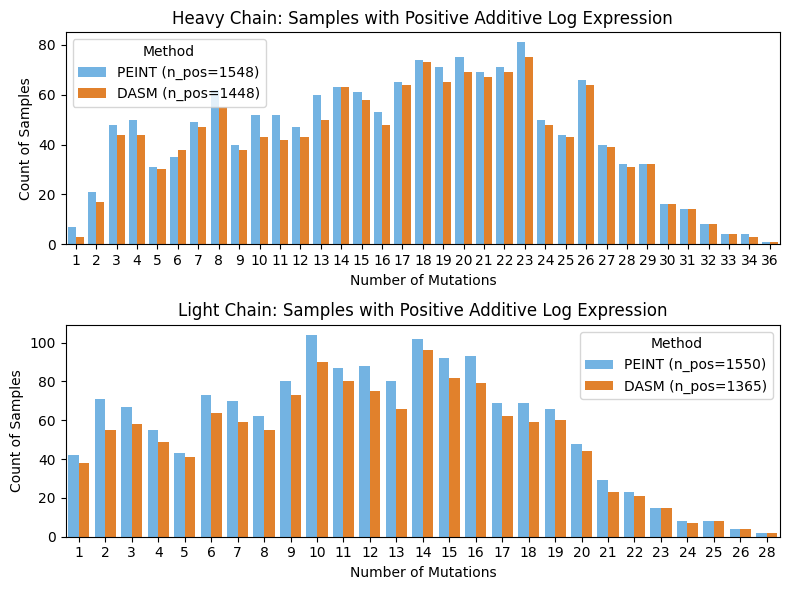

In [17]:
dataset = 'expression'  # 'binding' or 'expression'

# prepare data for plotting
data_rows = []

# heavy chain - PEINT
for n_mut, fits in peint_hv_fits_by_n_muts.items():
    count_positive = sum(1 for f in fits if f > 0)
    if count_positive <= 0: continue
    data_rows.append({
        'n_mutations': n_mut,
        'count_positive': count_positive,
        'method': 'PEINT',
        'chain': 'Heavy'
    })

# heavy chain - DASM
for n_mut, fits in dasm_hv_fits_by_n_muts.items():
    count_positive = sum(1 for f in fits if f > 0)
    if count_positive <= 0: continue
    data_rows.append({
        'n_mutations': n_mut,
        'count_positive': count_positive,
        'method': 'DASM',
        'chain': 'Heavy'
    })

# light chain - PEINT
for n_mut, fits in peint_lv_fits_by_n_muts.items():
    count_positive = sum(1 for f in fits if f > 0)
    if count_positive <= 0: continue
    data_rows.append({
        'n_mutations': n_mut,
        'count_positive': count_positive,
        'method': 'PEINT',
        'chain': 'Light'
    })

# light chain - DASM
for n_mut, fits in dasm_lv_fits_by_n_muts.items():
    count_positive = sum(1 for f in fits if f > 0)
    if count_positive <= 0: continue
    data_rows.append({
        'n_mutations': n_mut,
        'count_positive': count_positive,
        'method': 'DASM',
        'chain': 'Light'
    })

plot_df = pd.DataFrame(data_rows)

# create side-by-side barplots
fig, axes = plt.subplots(2, 1, figsize=(8,6))

palette = {'PEINT': "#60b6f4", 'DASM': "#ff7f0e"}

# heavy chain
heavy_data = plot_df[plot_df['chain'] == 'Heavy']
heavy_tot = heavy_data.groupby(by='method')['count_positive'].sum().to_dict()

if len(heavy_data) > 0:
    sns.barplot(data=heavy_data, x='n_mutations', y='count_positive', hue='method',
                palette=palette, ax=axes[0])
    axes[0].set_title(f'Heavy Chain: Samples with Positive Additive Log {dataset.capitalize()}')
    axes[0].set_xlabel('Number of Mutations')
    axes[0].set_ylabel('Count of Samples')
    # update legend labels to include totals
    handles, labels = axes[0].get_legend_handles_labels()
    new_labels = [f"{lab} (n_pos={heavy_tot.get(lab, 0)})" for lab in labels]
    axes[0].legend(handles, new_labels, title='Method')

# light chain
light_data = plot_df[plot_df['chain'] == 'Light']
light_tot = light_data.groupby(by='method')['count_positive'].sum().to_dict()

if len(light_data) > 0:
    sns.barplot(data=light_data, x='n_mutations', y='count_positive', hue='method',
                palette=palette, ax=axes[1])
    axes[1].set_title(f'Light Chain: Samples with Positive Additive Log {dataset.capitalize()}')
    axes[1].set_xlabel('Number of Mutations')
    axes[1].set_ylabel('Count of Samples')
    handles, labels = axes[1].get_legend_handles_labels()
    new_labels = [f"{lab} (n_pos={light_tot.get(lab, 0)})" for lab in labels]
    axes[1].legend(handles, new_labels, title='Method')

plt.tight_layout()
plt.show()


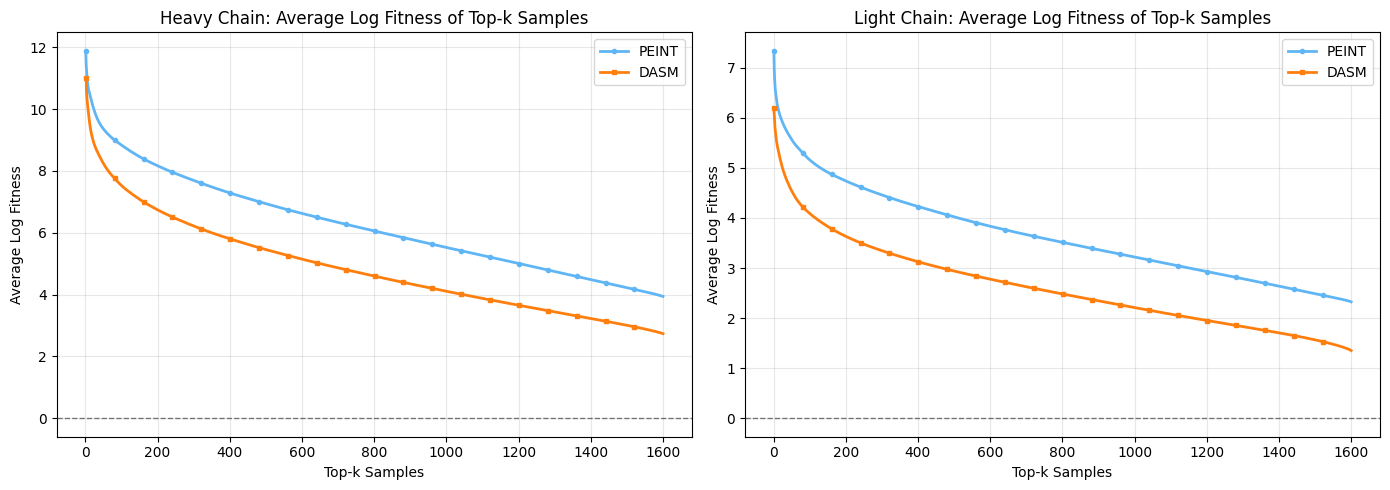


Summary: Top-k where average log fitness crosses 0
Heavy Chain - PEINT: k=1600, avg=3.9411
Heavy Chain - DASM: k=1600, avg=2.7391
Light Chain - PEINT: k=1600, avg=2.3248
Light Chain - DASM: k=1600, avg=1.3526


In [18]:
# Plot average log fitness of top-k samples for both methods and chains
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'PEINT': "#60b6f4", 'DASM': "#ff7f0e"}

# Helper function to compute top-k average
def compute_topk_avg(fits_dict):
    """Compute average of top-k samples until average becomes <= 0"""
    all_fits = []
    for n_mut, fits in fits_dict.items():
        all_fits.extend(fits)
    
    # Sort in descending order
    all_fits_sorted = sorted(all_fits, reverse=True)
    
    k_values = []
    avg_values = []
    
    for k in range(1, len(all_fits_sorted) + 1):
        avg = np.mean(all_fits_sorted[:k])
        k_values.append(k)
        avg_values.append(avg)
        
        # Stop when average becomes <= 0
        if avg <= 0:
            break
    
    return k_values, avg_values

# Heavy chain
peint_hv_k, peint_hv_avg = compute_topk_avg(peint_hv_fits_by_n_muts)
dasm_hv_k, dasm_hv_avg = compute_topk_avg(dasm_hv_fits_by_n_muts)

axes[0].plot(peint_hv_k, peint_hv_avg, color=palette['PEINT'], linewidth=2, label='PEINT', marker='o', markersize=3, markevery=max(1, len(peint_hv_k)//20))
axes[0].plot(dasm_hv_k, dasm_hv_avg, color=palette['DASM'], linewidth=2, label='DASM', marker='s', markersize=3, markevery=max(1, len(dasm_hv_k)//20))
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Top-k Samples')
axes[0].set_ylabel('Average Log Fitness')
axes[0].set_title('Heavy Chain: Average Log Fitness of Top-k Samples')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Light chain
peint_lv_k, peint_lv_avg = compute_topk_avg(peint_lv_fits_by_n_muts)
dasm_lv_k, dasm_lv_avg = compute_topk_avg(dasm_lv_fits_by_n_muts)

axes[1].plot(peint_lv_k, peint_lv_avg, color=palette['PEINT'], linewidth=2, label='PEINT', marker='o', markersize=3, markevery=max(1, len(peint_lv_k)//20))
axes[1].plot(dasm_lv_k, dasm_lv_avg, color=palette['DASM'], linewidth=2, label='DASM', marker='s', markersize=3, markevery=max(1, len(dasm_lv_k)//20))
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Top-k Samples')
axes[1].set_ylabel('Average Log Fitness')
axes[1].set_title('Light Chain: Average Log Fitness of Top-k Samples')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary: Top-k where average log fitness crosses 0")
print("="*70)
print(f"Heavy Chain - PEINT: k={peint_hv_k[-1] if peint_hv_k else 0}, avg={peint_hv_avg[-1] if peint_hv_avg else 0:.4f}")
print(f"Heavy Chain - DASM: k={dasm_hv_k[-1] if dasm_hv_k else 0}, avg={dasm_hv_avg[-1] if dasm_hv_avg else 0:.4f}")
print(f"Light Chain - PEINT: k={peint_lv_k[-1] if peint_lv_k else 0}, avg={peint_lv_avg[-1] if peint_lv_avg else 0:.4f}")
print(f"Light Chain - DASM: k={dasm_lv_k[-1] if dasm_lv_k else 0}, avg={dasm_lv_avg[-1] if dasm_lv_avg else 0:.4f}")


/tmp/ipykernel_3492543/2370424028.py:45: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(vals, ax=axes[0], color=color, bw_adjust=0.7, common_norm=False, linewidth=1.2, zorder=2)
/tmp/ipykernel_3492543/2370424028.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1.0])


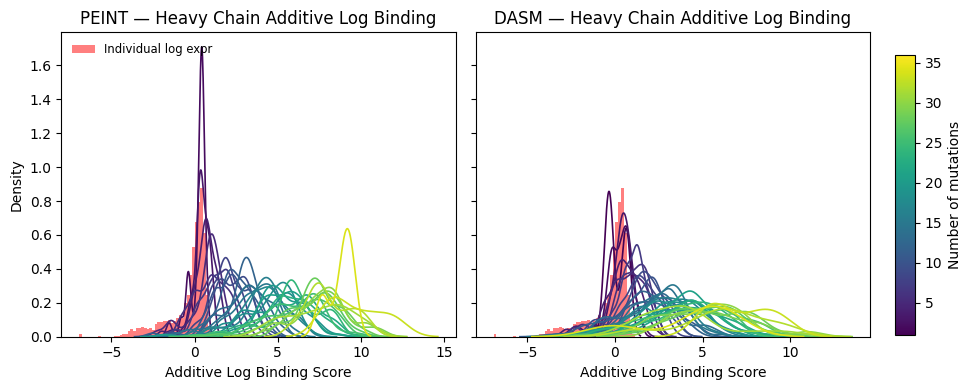

In [19]:
chain_choice = 'heavy'  # choose chain: 'heavy' or 'light'
dataset = 'binding'     # 'binding' or 'expression'

# map data structures based on chain choice
if chain_choice == 'heavy':
    n_muts_list = n_hv_muts
    peint_by_n = peint_hv_fits_by_n_muts
    dasm_by_n = dasm_hv_fits_by_n_muts
    df_chain = df_heavy
    title_chain = "Heavy Chain"
else:
    n_muts_list = n_lt_muts
    peint_by_n = peint_lv_fits_by_n_muts
    dasm_by_n = dasm_lv_fits_by_n_muts
    df_chain = df_light
    title_chain = "Light Chain"

# collect mutation counts for color mapping
peint_keys = sorted([int(k) for k in peint_by_n.keys()])
dasm_keys = sorted([int(k) for k in dasm_by_n.keys()])
all_unique = sorted(set(peint_keys + dasm_keys + [int(x) for x in n_muts_list]))
if len(all_unique) == 0:
    raise RuntimeError("No mutation counts available to plot")

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(all_unique), vmax=max(all_unique))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# background histogram of individual log-fitness (same background for both panels)
if 'fitness' in df_chain.columns and len(df_chain) > 0:
    log_vals = np.log(df_chain['fitness'].values.astype(float))
    weights = np.ones_like(log_vals) / len(log_vals) * 15
    for ax in axes:
        ax.hist(log_vals, bins=50, density=True, color='red', alpha=0.5, zorder=0, label='Individual log expr', weights=weights)

# left: PEINT
for n in sorted(peint_by_n.keys()):
    vals = peint_by_n.get(n, [])
    if len(vals) < 2:
        continue
    color = cmap(norm(int(n)))
    sns.kdeplot(vals, ax=axes[0], color=color, bw_adjust=0.7, common_norm=False, linewidth=1.2, zorder=2)

axes[0].set_title(f"PEINT — {title_chain} Additive Log {dataset.capitalize()}")
axes[0].set_xlabel(f"Additive Log {dataset.capitalize()} Score")
axes[0].set_ylabel("Density")
axes[0].legend(loc='upper left', frameon=False, fontsize='small')

# right: DASM
for n in sorted(dasm_by_n.keys()):
    vals = dasm_by_n.get(n, [])
    if len(vals) < 2:
        continue
    color = cmap(norm(int(n)))
    sns.kdeplot(vals, ax=axes[1], color=color, bw_adjust=0.7, common_norm=False, linewidth=1.2, zorder=2)

axes[1].set_title(f"DASM — {title_chain} Additive Log {dataset.capitalize()}")
axes[1].set_xlabel(f"Additive Log {dataset.capitalize()} Score")
# axes[1].legend(loc='upper left', frameon=False, fontsize='small')

# colorbar to the right (shared)
plt.subplots_adjust(right=0.88, wspace=0.35)
cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("Number of mutations")

# axes[0].set_yscale('log')
# axes[1].set_yscale('log')

plt.tight_layout(rect=[0, 0, 0.89, 1.0])
plt.show()

In [81]:
print(torch.nonzero(y_dec_diff_mask[0], as_tuple=True))

for idx in torch.nonzero(y_dec_diff_mask[0], as_tuple=True)[0]:
    print(idx.item())
    print(seed_seq[idx-1], y_seqs[0][idx-1], y_dasm_seqs[0][idx-1], sep=" | ")
    print()
# print(seed_seq)
# print(y_seqs[0])
# print(y_dasm_seqs[0])

(tensor([ 56,  61,  72, 149, 153], device='cuda:0'),)
56
G | D | D

61
A | T | G

72
A | R | V

149
D | S | Q

153
A | F | S



In [157]:
# sample 100 sequences from this starting heavy and light chain sequences using the probs
num_samples = 100
hv_seqs = []
hv_fits = []
lt_seqs = []
lt_fits = []
hv_hamming_dists = []
lt_hamming_dists = []

for _ in range(num_samples):
    # randomly sample 1-15 mutations for heavy and light chains from normal distribution with mean 8
    hv_n_muts = int(np.clip(np.random.normal(8, 3), 1, 15))
    lt_n_muts = int(np.clip(np.random.normal(8, 3), 1, 15))
    
    # sample n_muts position to mutate according to the unnormalized densities in hv_max_sf and lt_max_sf
    hv_mut_positions = torch.multinomial(hv_max_sf, hv_n_muts, replacement=False).tolist()
    lt_mut_positions = torch.multinomial(lt_max_sf, lt_n_muts, replacement=False).tolist()
    
    # sample new residues at each position
    if True:
        hv_sample = hv_argmax.tolist()
        lt_sample = lt_argmax.tolist()
    else:
        hv_sample = torch.multinomial(probs_hv, 1).squeeze().tolist()
        lt_sample = torch.multinomial(probs_lt, 1).squeeze().tolist()
    
    # assemble the sequences based on positions mutated
    hv_seq = "".join([_AA_STR_SORTED[aa_idx] if i in hv_mut_positions else koenig_hv_aa[i] for i, aa_idx in enumerate(hv_sample)])
    lt_seq = "".join([_AA_STR_SORTED[aa_idx] if i in lt_mut_positions else koenig_lv_aa[i] for i, aa_idx in enumerate(lt_sample)])

    # obtain mutant codes for each position in the new sequence with respect to the wildtypes koenig_hv_aa
    loc_hv_fits = []
    for idx, mut_aa, wt_aa in zip(range(len(hv_seq)), hv_seq, koenig_hv_aa):
        if mut_aa == wt_aa or idx == 0:
            continue
        mut_code = f"{wt_aa}{idx}{mut_aa}"
        if mut_code not in heavy_mut_codes:
            continue
        mut_fitness = df_heavy.loc[mut_code, "fitness"]
        loc_hv_fits.append(mut_fitness)

    # obtain mutant codes for each position in the new sequence with respect to the wildtypes koenig_lv_aa
    loc_lt_fits = []
    for idx, mut_aa, wt_aa in zip(range(len(lt_seq)), lt_seq, koenig_lv_aa):
        if mut_aa == wt_aa or idx == 0:
            continue
        mut_code = f"{wt_aa}{idx}{mut_aa}"
        if mut_code not in light_mut_codes:
            continue
        mut_fitness = df_light.loc[mut_code, "fitness"]
        loc_lt_fits.append(mut_fitness)

    if len(loc_hv_fits) == 0:
        hv_fits.append(1)
    else:
        mean_hv_fit = sum(loc_hv_fits) / len(loc_hv_fits)
        hv_fits.append(mean_hv_fit)
        
    if len(loc_lt_fits) == 0:
        lt_fits.append(1)
    else:
        mean_lt_fit = sum(loc_lt_fits) / len(loc_lt_fits)
        lt_fits.append(mean_lt_fit)
        
    hv_hamming_dists.append(compute_hamming_distance(hv_seq, koenig_hv_aa))
    lt_hamming_dists.append(compute_hamming_distance(lt_seq, koenig_lv_aa))
    
    hv_seqs.append(hv_seq)
    lt_seqs.append(lt_seq)

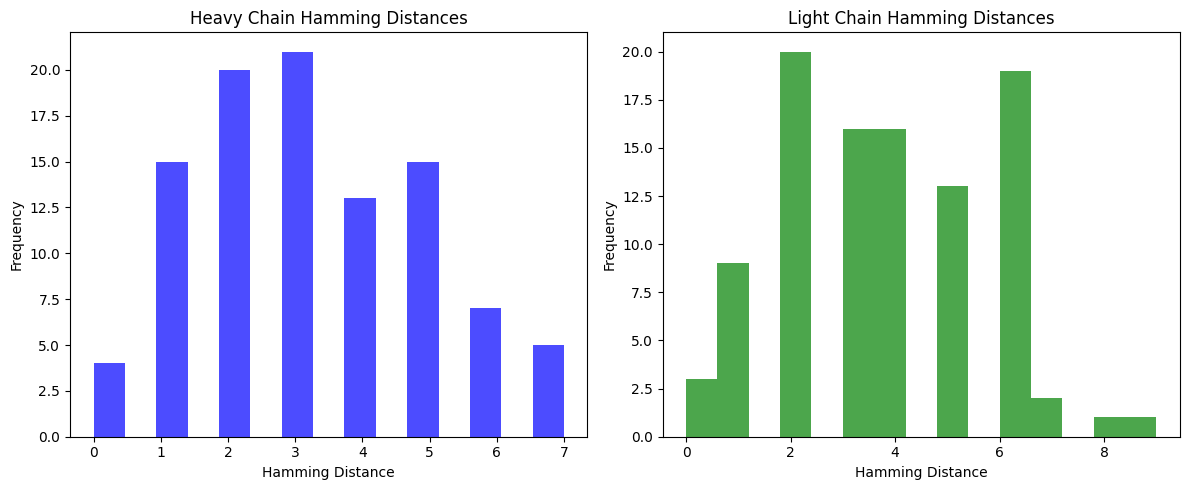

In [158]:
# plot a histogram of the Hamming distances for the heavy (left) and light (right) chains
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(hv_hamming_dists, bins=15, color='blue', alpha=0.7)
plt.title('Heavy Chain Hamming Distances')
plt.xlabel('Hamming Distance')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(lt_hamming_dists, bins=15, color='green', alpha=0.7)
plt.title('Light Chain Hamming Distances')
plt.xlabel('Hamming Distance')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

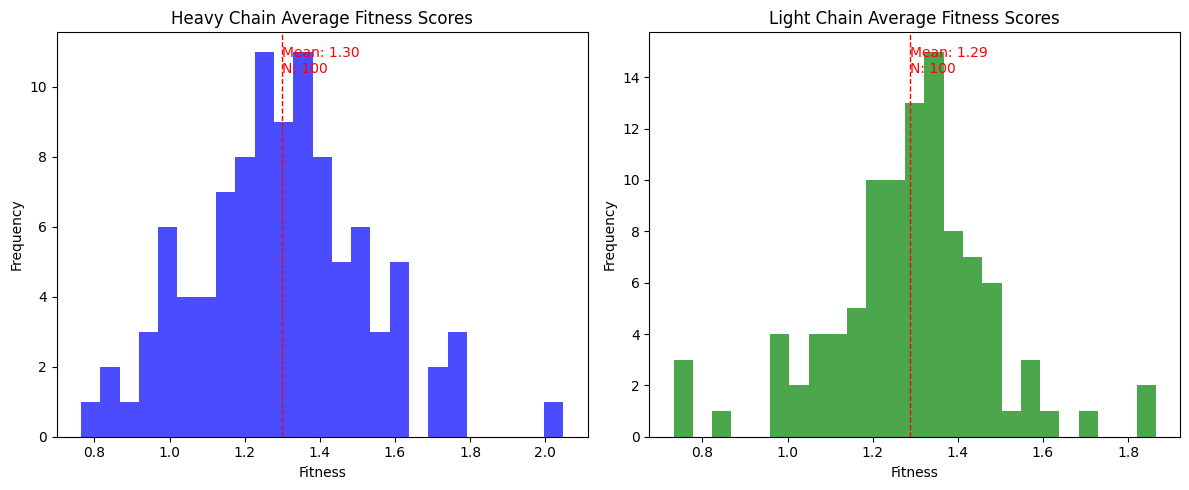

In [159]:
# plot a histogram of the fitness scores for the heavy (left) and light (right) chains
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(hv_fits, bins=25, color='blue', alpha=0.7)
plt.title('Heavy Chain Average Fitness Scores')
plt.xlabel('Fitness')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(lt_fits, bins=25, color='green', alpha=0.7)
plt.title('Light Chain Average Fitness Scores')
plt.xlabel('Fitness')
plt.ylabel('Frequency')

# add labels for mean and also show number of samples
hv_mean = sum(hv_fits) / len(hv_fits)
lt_mean = sum(lt_fits) / len(lt_fits)

plt.subplot(1, 2, 1)
plt.axvline(hv_mean, color='red', linestyle='dashed', linewidth=1)
plt.text(hv_mean, plt.ylim()[1]*0.9, f'Mean: {hv_mean:.2f}\nN: {len(hv_fits)}', color='red')

plt.subplot(1, 2, 2)
plt.axvline(lt_mean, color='red', linestyle='dashed', linewidth=1)
plt.text(lt_mean, plt.ylim()[1]*0.9, f'Mean: {lt_mean:.2f}\nN: {len(lt_fits)}', color='red')

plt.tight_layout()
plt.show()